# FinOptix - FAC Summer Project '25

# Assignment - 4

# Black-Litterman Model Implementation

This notebook is part of the FinOptix summer project assignment-4.

You are expected to fill in the missing parts to complete the model.

In [26]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [27]:
# Step 1: Define your stock universe
stocks = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'JNJ', 'PG',
    'V', 'MA', 'HD', 'DIS', 'PFE', 'KO', 'PEP', 'ADBE', 'INTC', 'NFLX'
]

In [28]:
# Step 2: Download historical data
# --- STUDENTS: Observe the structure and format of the downloaded data ---
data = yf.download(stocks, start="2020-01-01", end="2024-12-31")['Close']
data.dropna(axis=1, inplace=True)  # Drop stocks with missing data

/tmp/ipython-input-28-1147030998.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2024-12-31")['Close']
[*********************100%***********************]  20 of 20 completed


In [29]:
# Step 3: Calculate log returns
# --- STUDENTS: Write a function to calculate log returns ---
def calculate_log_returns(price_df):
    # TODO: Return log( P_t / P_(t-1) )
    return np.log(price_df / price_df.shift(1))


In [30]:
returns = calculate_log_returns(data)

In [31]:
# Step 4: Estimate the sample mean and covariance
mu_sample = returns.mean()
cov_sample = returns.cov()

In [32]:
# Step 5: Assume equal weights for market portfolio (simplification)
w_mkt = np.ones(len(returns.columns)) / len(returns.columns)

In [33]:
# Step 6: Compute implied equilibrium returns (Pi)
# --- STUDENTS: Fill in this function ---
def implied_returns(cov_matrix, market_weights, risk_aversion):
    # TODO: Pi = delta * Sigma * w_mkt
    return risk_aversion * cov_matrix @ market_weights

In [34]:
risk_aversion = 2.5  # Typical value from literature
pi = implied_returns(cov_sample, w_mkt, risk_aversion)

In [35]:
# Step 7: Formulate Views
# View 1: AAPL will outperform MSFT by 2%
# View 2: TSLA will underperform NVDA by 3%
# View 3: AMZN will outperform DIS by 1.5%
P = np.zeros((3, len(stocks)))
P[0, stocks.index('AAPL')] = 1
P[0, stocks.index('MSFT')] = -1
P[1, stocks.index('TSLA')] = -1
P[1, stocks.index('NVDA')] = 1
P[2, stocks.index('AMZN')] = 1
P[2, stocks.index('DIS')] = -1

Q = np.array([0.02, -0.03, 0.015])

In [36]:
# Step 8: Define the Omega matrix (view uncertainty)
# --- STUDENTS: Fill in reasonable uncertainties for each view ---
Omega = np.diag([0.0001, 0.0001, 0.0001])  # TODO: Fill in based on confidence (e.g. 0.0001)

In [37]:
# Step 9: Implement the Black-Litterman Posterior
# --- STUDENTS: Fill in the matrix math for μ_bl and Σ_bl ---
def black_litterman_posterior(cov, pi, P, Q, Omega, tau=0.025):
    # TODO: Implement
    # τΣ: scaled prior covariance
    # μ_bl = [(τΣ)^(-1) + PᵀΩ⁻¹P]^(-1) * [(τΣ)^(-1)π + PᵀΩ⁻¹Q]
    # Σ_bl = [(τΣ)^(-1) + PᵀΩ⁻¹P]^(-1)
    tau_cov = tau * cov

    inv_tau_cov = np.linalg.inv(tau_cov)
    inv_Omega = np.linalg.inv(Omega)

    M = np.linalg.inv(inv_tau_cov + P.T @ inv_Omega @ P)
    mu_bl = M @ (inv_tau_cov @ pi + P.T @ inv_Omega @ Q)

    return mu_bl, M


In [38]:
mu_bl, cov_bl = black_litterman_posterior(cov_sample, pi, P, Q, Omega)

In [39]:
!pip install PyPortfolioOpt


In [53]:
# Step 10: Perform Portfolio Optimization
# --- STUDENTS: Fill in optimizer function to compute optimal weights ---
# Tip: Use scipy.optimize.minimize or cvxpy for quadratic programming

#using PyPortfolioOpt
from pypfopt.efficient_frontier import EfficientFrontier
def mean_variance_opt(mu, cov, allow_short=False):
    ef = EfficientFrontier(mu,cov)
    ef.max_sharpe()
    return ef.clean_weights()

In [54]:
optimal_weights = mean_variance_opt(mu_bl, cov_bl)

In [55]:
optimal_weights = np.array(list(optimal_weights.items()))

In [56]:
optimal_weights = np.array(list(optimal_weights[x][1] for x in range(len(optimal_weights))))
optimal_weights

array([0.     , 0.     , 0.     , 0.08628, 0.     , 0.59765, 0.     ,
       0.03025, 0.     , 0.28583, 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     ])

In [57]:
w_mkt

array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])

In [59]:
pd.Series(optimal_weights, index=returns.columns)

,0
Ticker,
AAPL,0.00000
ADBE,0.00000
AMZN,0.00000
DIS,0.08628
GOOGL,0.00000
HD,0.59765
INTC,0.00000
JNJ,0.03025
JPM,0.00000


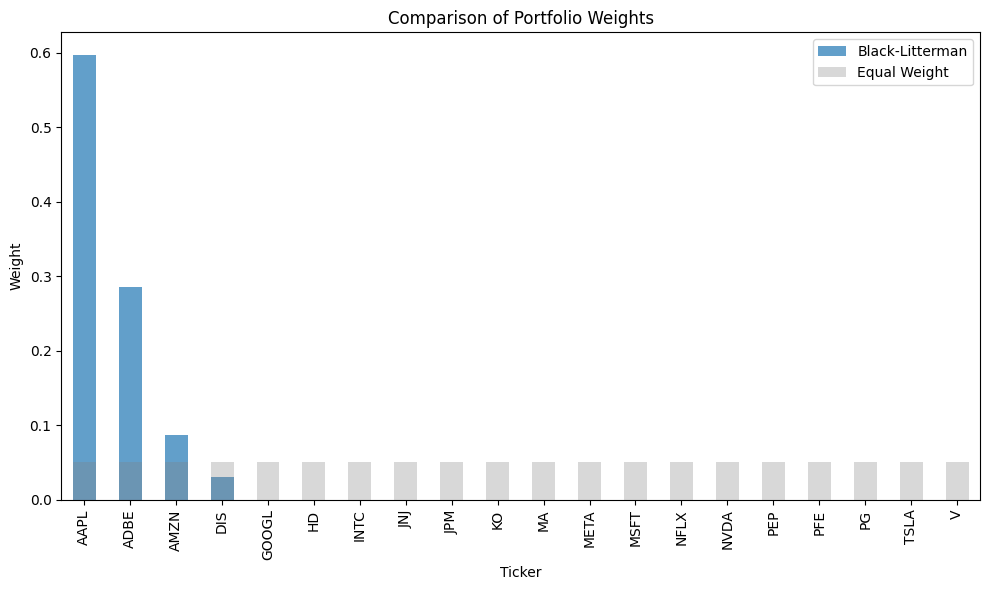

In [60]:
# Step 11: Analyze and Compare Portfolios
# --- STUDENTS: Plot and compare ---
portfolio_bl = pd.Series(optimal_weights, index=returns.columns)
portfolio_bl = portfolio_bl[portfolio_bl > 0.01].sort_values(ascending=False)

# Also compare with naïve equal weight and market cap weight
portfolio_equal = pd.Series(w_mkt, index=returns.columns)
portfolio_equal = portfolio_equal[portfolio_equal > 0.01].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
portfolio_bl.plot(kind='bar', ax=ax, label='Black-Litterman', alpha=0.7)
portfolio_equal.plot(kind='bar', ax=ax, color='gray', label='Equal Weight', alpha=0.3)
plt.title('Comparison of Portfolio Weights')
plt.ylabel('Weight')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Step 12: Portfolio Performance Simulation
# --- STUDENTS: Evaluate performance ---
def simulate_portfolio(returns, weights):
    # TODO: Compute cumulative returns and plot
    portfolio_returns = returns @ weights
    cumulative_returns = (1 + portfolio_returns).cumprod()

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(cumulative_returns, label='Portfolio')
    plt.title("Portfolio Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return cumulative_returns

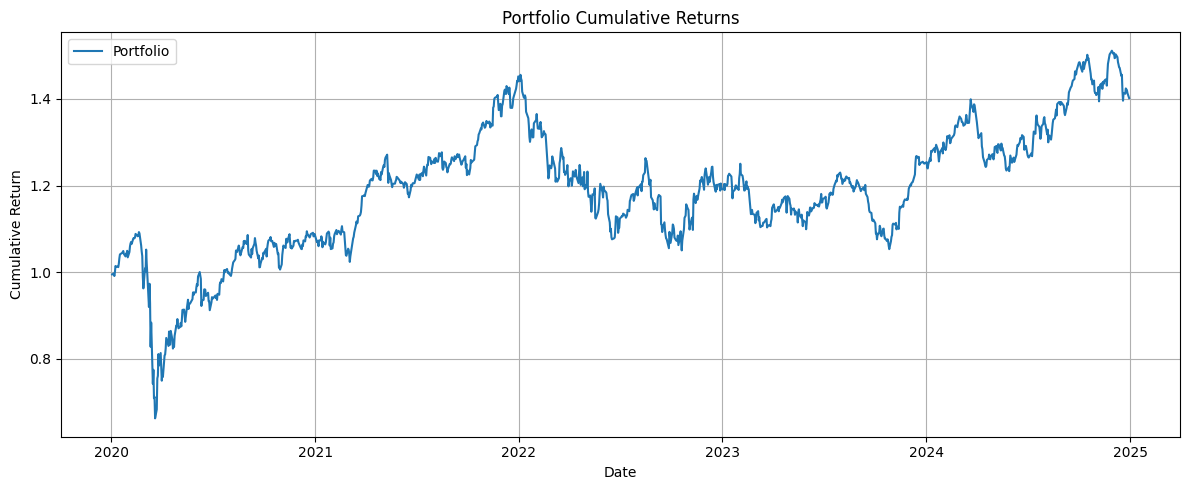

,0
Date,
2020-01-02,NaN
2020-01-03,0.995099
2020-01-06,0.997249
2020-01-07,0.991350
2020-01-08,1.000491
...,...
2024-12-23,1.411970
2024-12-24,1.424265
2024-12-26,1.420270


In [63]:
simulate_portfolio(returns, optimal_weights)  # Uncomment once implemented

In [ ]:
# --- END OF EXTENDED NOTEBOOK ---